<a href="https://colab.research.google.com/github/poosathanusri06/CodeAlpha_internshipwork/blob/main/TASK3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_565/673817380.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start="2025-01-01", periods=12, freq="M")
/tmp/ipykernel_565/673817380.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_profit, x='Region', y='Profit', palette='Blues_d', ax=ax2)


Dashboard visual saved successfully as 'sales_insights_dashboard.png'.


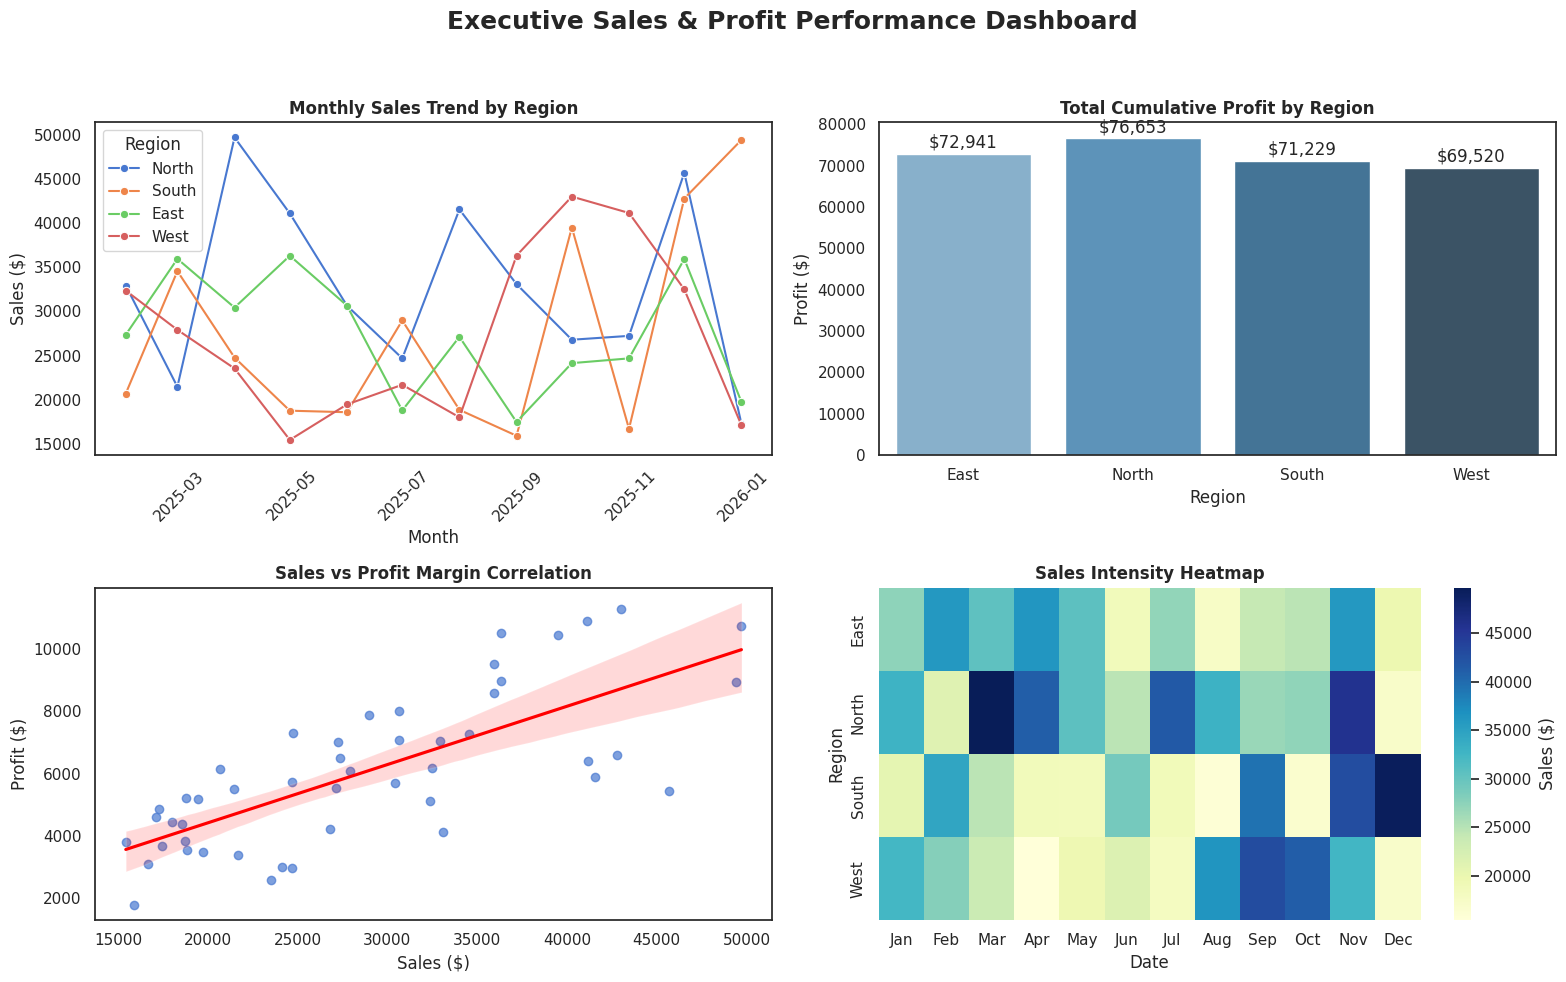

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def generate_sales_data():
    """Generates synthetic sales data for story-driven visualization."""
    np.random.seed(101)
    dates = pd.date_range(start="2025-01-01", periods=12, freq="M")
    regions = ['North', 'South', 'East', 'West']

    records = []
    for date in dates:
        for region in regions:
            sales = np.random.randint(15000, 50000)
            profit = sales * np.random.uniform(0.1, 0.3)
            records.append({'Date': date, 'Region': region, 'Sales': sales, 'Profit': profit})

    return pd.DataFrame(records)

def create_dashboard(df):
    """Creates a multi-panel visual dashboard with statistical insights."""
    # Set global aesthetic theme
    sns.set_theme(style="white", palette="muted")
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle("Executive Sales & Profit Performance Dashboard", fontsize=18, fontweight='bold', y=0.98)

    # 1. Line Chart: Sales Trend Over Time by Region
    ax1 = plt.subplot(2, 2, 1)
    sns.lineplot(data=df, x='Date', y='Sales', hue='Region', marker='o', ax=ax1)
    ax1.set_title("Monthly Sales Trend by Region", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Sales ($)")
    plt.xticks(rotation=45)

    # 2. Bar Chart: Total Profit by Region
    ax2 = plt.subplot(2, 2, 2)
    region_profit = df.groupby('Region')['Profit'].sum().reset_index()
    sns.barplot(data=region_profit, x='Region', y='Profit', palette='Blues_d', ax=ax2)
    ax2.set_title("Total Cumulative Profit by Region", fontsize=12, fontweight='bold')
    ax2.set_ylabel("Profit ($)")
    for p in ax2.patches:
        ax2.annotate(f"${p.get_height():,.0f}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points')

    # 3. Scatter Plot: Sales vs Profit Relationship
    ax3 = plt.subplot(2, 2, 3)
    sns.regplot(data=df, x='Sales', y='Profit', ax=ax3, scatter_kws={'alpha':0.7}, line_kws={'color': 'red'})
    ax3.set_title("Sales vs Profit Margin Correlation", fontsize=12, fontweight='bold')
    ax3.set_xlabel("Sales ($)")
    ax3.set_ylabel("Profit ($)")

    # 4. Heatmap: Monthly Regional Sales Intensity
    ax4 = plt.subplot(2, 2, 4)
    pivot_df = df.pivot(index='Region', columns='Date', values='Sales')
    pivot_df.columns = pivot_df.columns.strftime('%b')
    sns.heatmap(pivot_df, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Sales ($)'}, ax=ax4)
    ax4.set_title("Sales Intensity Heatmap", fontsize=12, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig("sales_insights_dashboard.png", dpi=300)
    print("Dashboard visual saved successfully as 'sales_insights_dashboard.png'.")
    plt.show()

if __name__ == "__main__":
    sales_df = generate_sales_data()
    create_dashboard(sales_df)